In [1]:
"""
Этап 3. ABC-анализ по выручке.

Группы:
- A — первые ~80% выручки.
- B — следующие ~15%.
- C — оставшиеся ~5%.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
abc = read_sql("""
    SELECT
        stock_code,
        MAX(description)                     AS description,
        COUNT(DISTINCT invoice_no)           AS orders,
        COUNT(DISTINCT customer_id)          AS customers,
        COUNT(DISTINCT month_start)          AS active_months,
        SUM(quantity)                        AS total_quantity,
        ROUND(SUM(revenue)::numeric, 2)      AS revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC;
""")

# Приводим типы
abc["revenue"] = abc["revenue"].astype(float)
abc["total_quantity"] = abc["total_quantity"].astype(int)
abc["orders"] = abc["orders"].astype(int)
abc["customers"] = abc["customers"].astype(int)
abc["active_months"] = abc["active_months"].astype(int)

print(f"Всего SKU: {len(abc):,}")
print(f"Общая выручка: £{abc['revenue'].sum():,.2f}")
print(f"\nТоп-10 по выручке:")
display(abc.head(10))

Всего SKU: 4,895
Общая выручка: £20,109,033.72

Топ-10 по выручке:


,stock_code,description,orders,customers,active_months,total_quantity,revenue
0,22423,REGENCY CAKESTAND 3 TIER,3918,1314,22,27577,"344,563.25"
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5365,1490,25,96147,"263,109.67"
2,85099B,RED RETROSPOT JUMBO BAG,3989,978,25,98349,"183,454.83"
3,23843,"PAPER CRAFT , LITTLE BIRDIE",1,1,1,80995,"168,469.60"
4,47566,PARTY BUNTING,2674,894,25,28378,"149,187.05"
5,84879,ASSORTED COLOUR BIRD ORNAMENT,2807,1010,25,81809,"132,187.92"
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2018,896,24,36581,"123,141.54"
7,79321,CHILLI LIGHTS,1135,304,25,16840,"85,489.91"
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,247,138,9,78033,"81,700.92"
9,22197,SMALL POPCORN HOLDER,2322,601,25,89898,"80,920.64"


In [3]:
abc["revenue_share"] = abc["revenue"] / abc["revenue"].sum()
abc["cum_revenue_share"] = abc["revenue_share"].cumsum()
abc["cum_sku_share"] = (np.arange(1, len(abc) + 1)) / len(abc)

print("Готово. Первые 5 строк:")
display(abc[[
    "stock_code", "description", "revenue",
    "revenue_share", "cum_revenue_share", "cum_sku_share"
]].head())

Готово. Первые 5 строк:


,stock_code,description,revenue,revenue_share,cum_revenue_share,cum_sku_share
0,22423,REGENCY CAKESTAND 3 TIER,"344,563.25",0.02,0.02,0.00
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"263,109.67",0.01,0.03,0.00
2,85099B,RED RETROSPOT JUMBO BAG,"183,454.83",0.01,0.04,0.00
3,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",0.01,0.05,0.00
4,47566,PARTY BUNTING,"149,187.05",0.01,0.06,0.00


In [4]:
abc["abc_category"] = np.select(
    [
        abc["cum_revenue_share"] <= 0.80,
        abc["cum_revenue_share"] <= 0.95,
    ],
    ["A", "B"],
    default="C",
)

# Сводка
abc_summary = (
    abc.groupby("abc_category")
    .agg(
        skus=("stock_code", "count"),
        revenue=("revenue", "sum"),
        units=("total_quantity", "sum"),
        orders=("orders", "sum"),
    )
)
abc_summary["sku_share_pct"] = abc_summary["skus"] / abc_summary["skus"].sum() * 100
abc_summary["revenue_share_pct"] = abc_summary["revenue"] / abc_summary["revenue"].sum() * 100

print("Сводка по категориям A/B/C:")
display(abc_summary[[
    "skus", "sku_share_pct", "revenue", "revenue_share_pct", "orders"
]].round(2))

Сводка по категориям A/B/C:


,skus,sku_share_pct,revenue,revenue_share_pct,orders
abc_category,,,,,
A,1035,21.14,"16,086,216.32",79.99,653722
B,1278,26.11,"3,016,555.03",15.00,233863
C,2582,52.75,"1,006,262.37",5.00,104374


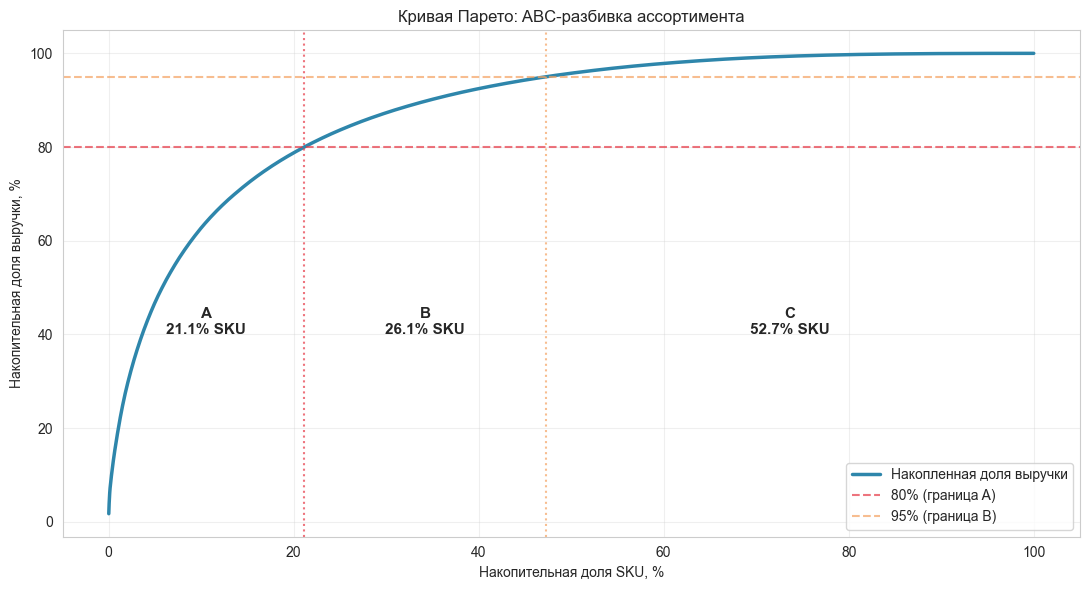

Границы:
  A: до 21.14% SKU
  B: до 47.25% SKU
  C: остальные 52.75% SKU


In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# Основная кривая
ax.plot(
    abc["cum_sku_share"] * 100,
    abc["cum_revenue_share"] * 100,
    linewidth=2.5, color="#2E86AB", label="Накопленная доля выручки",
)

# Горизонтальные границы
ax.axhline(80, linestyle="--", color="#E63946", alpha=0.7, label="80% (граница A)")
ax.axhline(95, linestyle="--", color="#F4A261", alpha=0.7, label="95% (граница B)")

# Находим X-координаты пересечений
n_a = (abc["abc_category"] == "A").sum() / len(abc) * 100
n_ab = ((abc["abc_category"] == "A") | (abc["abc_category"] == "B")).sum() / len(abc) * 100

ax.axvline(n_a, linestyle=":", color="#E63946", alpha=0.7)
ax.axvline(n_ab, linestyle=":", color="#F4A261", alpha=0.7)

# Подписи зон
ax.text(n_a / 2, 40, f"A\n{n_a:.1f}% SKU", ha="center", fontsize=11, fontweight="bold")
ax.text((n_a + n_ab) / 2, 40, f"B\n{(n_ab - n_a):.1f}% SKU", ha="center", fontsize=11, fontweight="bold")
ax.text((n_ab + 100) / 2, 40, f"C\n{(100 - n_ab):.1f}% SKU", ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Накопительная доля SKU, %")
ax.set_ylabel("Накопительная доля выручки, %")
ax.set_title("Кривая Парето: ABC-разбивка ассортимента")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "abc_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Границы:")
print(f"  A: до {n_a:.2f}% SKU")
print(f"  B: до {n_ab:.2f}% SKU")
print(f"  C: остальные {100 - n_ab:.2f}% SKU")

In [6]:
print("=" * 80)
print("ТОП-15 группы A (ключевые товары бизнеса):")
print("=" * 80)
display(
    abc[abc["abc_category"] == "A"]
    .head(15)[[
        "stock_code", "description", "revenue", "revenue_share",
        "orders", "customers", "active_months",
    ]]
)

print("\n" + "=" * 80)
print("Примеры группы C (низкий вклад в выручку):")
print("=" * 80)
display(
    abc[abc["abc_category"] == "C"]
    .sample(15, random_state=42)[[
        "stock_code", "description", "revenue", "revenue_share",
        "orders", "customers", "active_months",
    ]]
)

ТОП-15 группы A (ключевые товары бизнеса):


,stock_code,description,revenue,revenue_share,orders,customers,active_months
0,22423,REGENCY CAKESTAND 3 TIER,"344,563.25",0.02,3918,1314,22
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"263,109.67",0.01,5365,1490,25
2,85099B,RED RETROSPOT JUMBO BAG,"183,454.83",0.01,3989,978,25
3,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",0.01,1,1,1
4,47566,PARTY BUNTING,"149,187.05",0.01,2674,894,25
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"132,187.92",0.01,2807,1010,25
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"123,141.54",0.01,2018,896,24
7,79321,CHILLI LIGHTS,"85,489.91",0.00,1135,304,25
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",0.00,247,138,9
9,22197,SMALL POPCORN HOLDER,"80,920.64",0.00,2322,601,25



Примеры группы C (низкий вклад в выручку):


,stock_code,description,revenue,revenue_share,orders,customers,active_months
3122,23473,WOODLAND SMALL RED FELT HEART,552.85,0.00,51,41,3
3759,22883,"NUMBER TILE VINTAGE FONT, 4",217.26,0.00,34,9,14
3074,23565,EGG CUP MILKMAID HELGA,586.31,0.00,63,28,3
2631,35598B,BLACK CHRISTMAS TREE 60CM,911.77,0.00,57,37,13
3274,90145,SILVER HOOP EARRINGS WITH FLOWER,461.81,0.00,45,16,21
4881,85231e,STRAWBERRY SCENTED SET/9 T-LIGHTS,1.66,0.00,1,0,1
4808,20877,MODERN CHRISTMAS BAUBLE CANDLE,5.04,0.00,5,3,1
4003,90003E,GREEN PAIR HEART HAIR SLIDES,131.62,0.00,22,3,14
3824,84706B,FAIRY CAKES TABLE CLOCK,188.73,0.00,9,8,3
4740,90013E,AMBER VINTAGE EARRINGS,8.57,0.00,2,0,2


In [7]:
print("Товары группы A с очень малым числом заказов (аномалии):")
print("Признак: 1-2 заказа, но высокая выручка")
print("=" * 80)

anomalies = abc[
    (abc["abc_category"] == "A")
    & (abc["orders"] <= 2)
].sort_values("revenue", ascending=False)

display(anomalies[[
    "stock_code", "description", "revenue", "orders",
    "customers", "active_months", "total_quantity",
]])

print(f"\nВсего таких SKU в A: {len(anomalies)}")
print(f"Их суммарная выручка: £{anomalies['revenue'].sum():,.2f} "
      f"({anomalies['revenue'].sum() / abc['revenue'].sum() * 100:.2f}% от всей)")

Товары группы A с очень малым числом заказов (аномалии):
Признак: 1-2 заказа, но высокая выручка


,stock_code,description,revenue,orders,customers,active_months,total_quantity
3,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",1,1,1,80995



Всего таких SKU в A: 1
Их суммарная выручка: £168,469.60 (0.84% от всей)


In [8]:
# Сохраняем таблицу abc в Postgres через psycopg2 (без SQLAlchemy)

# Формируем таблицу для сохранения
abc_for_db = abc[[
    "stock_code", "description", "revenue", "revenue_share",
    "cum_revenue_share", "cum_sku_share", "total_quantity",
    "orders", "customers", "active_months", "abc_category",
]].copy()

# Формируем DDL
create_table_sql = """
DROP TABLE IF EXISTS abc;
CREATE TABLE abc (
    stock_code        text,
    description       text,
    revenue           numeric,
    revenue_share     numeric,
    cum_revenue_share numeric,
    cum_sku_share     numeric,
    total_quantity    bigint,
    orders            integer,
    customers         integer,
    active_months     integer,
    abc_category      text
);
"""

# Выполняем DDL
execute_sql(create_table_sql)

# Вставляем данные батчами
insert_sql = """
INSERT INTO abc (
    stock_code, description, revenue, revenue_share,
    cum_revenue_share, cum_sku_share, total_quantity,
    orders, customers, active_months, abc_category
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
"""

# Конвертируем DataFrame в список кортежей
rows = [tuple(r) for r in abc_for_db.itertuples(index=False, name=None)]

# Открываем соединение напрямую через psycopg2
import psycopg2
from scripts.db_config import _get_conn_params

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        # executemany эффективно вставляет пачками
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица abc сохранена в Postgres ({len(rows):,} строк)")

# Проверка
check = read_sql("""
    SELECT abc_category, COUNT(*) AS n
    FROM abc
    GROUP BY abc_category
    ORDER BY abc_category;
""")
print("\nПроверка:")
display(check)

✅ Таблица abc сохранена в Postgres (4,895 строк)

Проверка:


,abc_category,n
0,A,1035
1,B,1278
2,C,2582


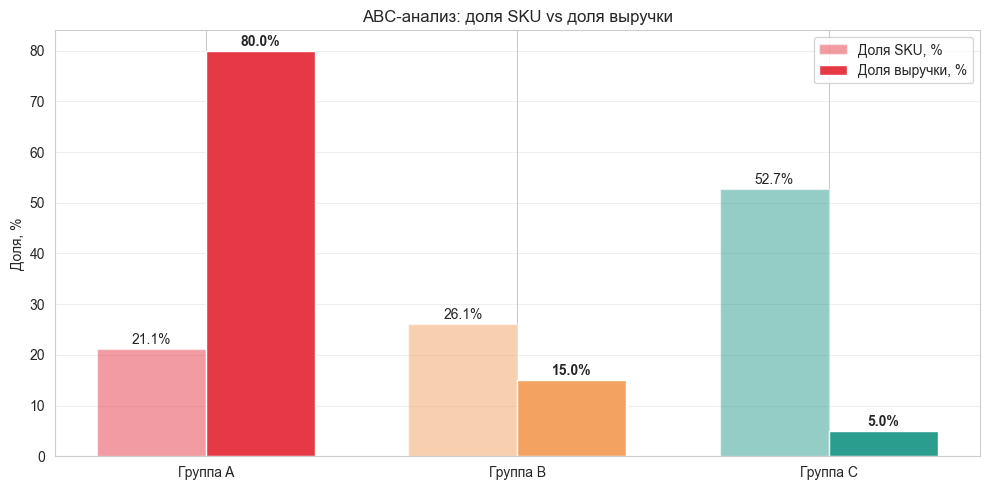

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {"A": "#E63946", "B": "#F4A261", "C": "#2A9D8F"}
order = ["A", "B", "C"]

# Левая ось — SKU
x = np.arange(len(order))
width = 0.35

sku_counts = abc_summary.loc[order, "skus"].values
rev_shares = abc_summary.loc[order, "revenue_share_pct"].values
sku_shares = abc_summary.loc[order, "sku_share_pct"].values

bars1 = ax.bar(x - width/2, sku_shares, width, label="Доля SKU, %",
               color=[colors[c] for c in order], alpha=0.5)
bars2 = ax.bar(x + width/2, rev_shares, width, label="Доля выручки, %",
               color=[colors[c] for c in order])

for bar, val in zip(bars1, sku_shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=10)
for bar, val in zip(bars2, rev_shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"Группа {c}" for c in order])
ax.set_ylabel("Доля, %")
ax.set_title("ABC-анализ: доля SKU vs доля выручки")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "abc_sku_vs_revenue.png", dpi=120, bbox_inches="tight")
plt.show()

## Этап 3. ABC-анализ по выручке — ВЫВОДЫ

### Что сделано
Выручка агрегирована по StockCode. Все 4 895 SKU отсортированы по убыванию
выручки, рассчитаны доли и накопительная доля. Категории:
- **A** — накопленная доля выручки ≤ 80%.
- **B** — 80% < доля ≤ 95%.
- **C** — оставшиеся SKU (> 95%).

### Итоговое распределение

| Категория | SKU | Доля SKU | Выручка, £ | Доля выручки | Заказы |
|-----------|-----|----------|------------|--------------|--------|
| **A** | 1 035 | 21.14% | 16 086 216.32 | 79.99% | 653 722 |
| **B** | 1 278 | 26.11% | 3 016 555.03 | 15.00% | 233 863 |
| **C** | 2 582 | 52.75% | 1 006 262.37 | 5.00% | 104 374 |
| **Всего** | 4 895 | 100% | 20 109 033.72 | 100% | 991 959 |

Границы:
- **A:** первые 21.14% SKU дают ~80% выручки.
- **B:** следующие 26.11% SKU дают ~15% выручки.
- **C:** оставшиеся 52.75% SKU дают только ~5% выручки.

Распределение **точно совпало с классическими границами 80/15/5** —
мы их не подгоняли, так легли данные.

### Ключевые выводы

1. **Принцип Парето подтверждается в чистом виде.** 21% ассортимента
   формируют 80% выручки. Классическая структура для ритейла.

2. **Группа C — половина ассортимента, но всего 5% выручки.** Это первая
   подсказка для бизнес-задачи о сокращении ~20% SKU, но **не готовый
   список на удаление**. Причины:
   - часть товаров — дополнения к основным покупкам (роль в корзине);
   - часть — сезонные, продаются в конкретные месяцы;
   - часть — новые, ещё не раскрыли потенциал;
   - часть — привлекают новых клиентов в магазин.

3. **Группа A неоднородна.** Внутри неё:
   - **Лидеры с устойчивым спросом** (85123A, 85099B, 47566, 84879,
     22086) — 25 активных месяцев, тысячи заказов, сотни клиентов.
   - **SKU 23166 MEDIUM CERAMIC TOP STORAGE JAR** — 9 активных месяцев,
     247 заказов, £81 701. Сезонный/ограниченный товар.
   - **SKU 79321 CHILLI LIGHTS** — 25 месяцев, но 304 клиента.
     Нишевый товар с узкой клиентской базой.

4. **Обнаружена одна аномалия в группе A:**
   - **SKU 23843 (PAPER CRAFT, LITTLE BIRDIE)** — 1 заказ, 1 клиент,
     1 активный месяц, выручка £168 470 (0.84% от общей).
   - Формально A, фактически — **разовая оптовая сделка**.
   - В XYZ-анализе попадёт в Z, в матрице ABC/XYZ — в **A-no_data**.

5. **Товары группы C — не «плохие».** Примеры:
   - **90145 SILVER HOOP EARRINGS WITH FLOWER** — 45 заказов,
     21 активный месяц. Регулярный спрос. Возможен **CX**. Не удалять!
   - **90120A PINK MURANO TWIST BRACELET** — 41 заказ, 14 месяцев.
   - **20877 MODERN CHRISTMAS BAUBLE CANDLE** — 5 заказов, но
     **новогодний товар** — сезонный, может быть в **CY**.
   - **85231e STRAWBERRY SCENTED SET/9 T-LIGHTS** — 1 заказ, £1.66.
     Реальный кандидат на вывод (проверить отдельно).

6. **Итеративная очистка данных.** Финальные цифры получены после
   двух итераций очистки `sales`. Восстановление 36 товаров
   (кофейные кружки и др.) не изменило структуру ABC, но повлияло
   на состав групп B/C.

### Что зафиксировано в базе
Таблица `abc` (4 895 строк) сохранена в Postgres.

### Графики
- `reports/abc_pareto.png` — кривая Парето с границами A/B/C.
- `reports/abc_sku_vs_revenue.png` — SKU vs выручка.

### Что дальше
**Этап 4 (XYZ):** разбить ассортимент по стабильности спроса.
Дальше — матрица ABC/XYZ.